# Getting started with pyspi

pyspi computes **statistics of pairwise interactions** (SPIs) between the processes of a
multivariate time series. Each SPI is one way of answering "how are these two processes
related?" -- a correlation coefficient, a spectral coherence, a transfer entropy, a
causal-inference score. For a dataset of `M` processes, every SPI returns an `M x M` matrix
of pairwise values, and pyspi stacks all of those matrices into a single table so that
hundreds of different notions of "related" can be compared side by side.

This notebook covers: loading data, running a calculator, reading the results table, and
choosing a config.

> **Plotting requires matplotlib**, which is not a core pyspi dependency. Install it with
> `pip install matplotlib` (or `pip install "pyspi[bench]"`).

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspi.calculator import Calculator, bundled_configs
from pyspi.data import load_dataset, available_datasets

pd.set_option("display.width", 120)
available_datasets()

{'forex': 'Foreign-exchange rates (250 obs, 7 processes).',
 'cml': 'Coupled map lattice (500 obs, 10 processes).',
 'standard_normal': 'i.i.d. standard normal null model (200 obs, 5 processes).'}

## 1. Load a dataset

`load_dataset` returns a `Data` object: an `M x T` array of `M` processes by `T`
observations, z-scored per process by default. We use `forex`, a real dataset of
foreign-exchange rates.

Your own data goes in the same way: `Calculator(dataset=my_array)` accepts a NumPy array,
and `dim_order` on `Data` controls whether rows are processes or observations.

In [2]:
data = load_dataset("forex")
print(f"{data.n_processes} processes x {data.n_observations} observations")
print("process names:", data.procnames)

7 processes x 250 observations
process names: ['proc-0', 'proc-1', 'proc-2', 'proc-3', 'proc-4', 'proc-5', 'proc-6']


## 2. Run a calculator

`config` chooses which SPIs to compute. `fabfour` is the smallest bundled config: four
SPIs, one from each of four different families. `compute()` runs them all.

In [ ]:
calc = Calculator(dataset=data, 
                  config="fabfour", 
                  verbose=False)

t0 = time.perf_counter()
calc.compute(progress=False)
fabfour_seconds = time.perf_counter() - t0

print(f"{calc.n_spis} SPIs in {fabfour_seconds:.2f}s")
list(calc.spis)

4 SPIs in 0.02s


['cov_EmpiricalCovariance', 'spearmanr-sq', 'di_gaussian', 'pec']

## 3. Reading the results table

This is the part that trips people up, so it is worth being explicit.

`calc.table` is a `DataFrame` with

- **rows**: one per process (`calc.dataset.procnames`),
- **columns**: a two-level `MultiIndex` of `(spi, process)`.

So its shape is `M x (n_spis * M)`: every SPI's `M x M` matrix, laid side by side. The
diagonal of each matrix is always `NaN` -- self-pairs are not computed.

**Orientation matters.** Entry `[i, j]` is computed with process `i` as the *source* and
process `j` as the *target*. For an undirected SPI the matrix is symmetric and the
distinction is irrelevant; for a directed SPI it is the whole point.

In [4]:
print("table shape:", calc.table.shape)
print("column levels:", calc.table.columns.names)
calc.table.iloc[:3, :6]

table shape: (7, 28)
column levels: ['spi', 'process']


spi     cov_EmpiricalCovariance                                                  
process                  proc-0    proc-1    proc-2    proc-3    proc-4    proc-5
proc-0                      NaN -0.676742 -0.171030 -0.649407  0.382806 -0.539182
proc-1                -0.676742       NaN  0.150468  0.901080 -0.107627  0.416836
proc-2                -0.171030  0.150468       NaN  0.090539 -0.195452  0.141439

### Pulling out one SPI's matrix

Index the table with an SPI identifier to get that SPI's `M x M` matrix back as a
`DataFrame`, with processes on both axes.

In [5]:
cov = calc.table["cov_EmpiricalCovariance"]
cov.round(3)

process,proc-0,proc-1,proc-2,proc-3,proc-4,proc-5,proc-6
proc-0,NaN,-0.677,-0.171,-0.649,0.383,-0.539,0.482
proc-1,-0.677,NaN,0.150,0.901,-0.108,0.417,-0.859
proc-2,-0.171,0.150,NaN,0.091,-0.195,0.141,-0.016
proc-3,-0.649,0.901,0.091,NaN,-0.060,0.353,-0.816
proc-4,0.383,-0.108,-0.195,-0.060,NaN,-0.657,-0.271
proc-5,-0.539,0.417,0.141,0.353,-0.657,NaN,-0.204
proc-6,0.482,-0.859,-0.016,-0.816,-0.271,-0.204,NaN


### Pulling out a single pair

Because the data is z-scored, `cov_EmpiricalCovariance` is the Pearson correlation. Two
equivalent ways to get one pair, plus the raw two-level indexing on the full table.

In [6]:
print("proc-1 / proc-3 :", cov.loc["proc-1", "proc-3"].round(4))
print("via full table  :", calc.table.loc["proc-1", ("cov_EmpiricalCovariance", "proc-3")].round(4))

# All pairs, ranked, without the redundant lower triangle.
upper = cov.where(np.triu(np.ones(cov.shape), k=1).astype(bool))
upper.stack().abs().sort_values(ascending=False).head(5).round(3)

proc-1 / proc-3 : 0.9011
via full table  : 0.9011


        process
proc-1  proc-3     0.901
        proc-6     0.859
proc-3  proc-6     0.816
proc-0  proc-1     0.677
proc-4  proc-5     0.657
dtype: float64

### Directed vs undirected

`di_gaussian` (directed information) is directed, so its matrix is *not* symmetric.
Reading row `i`, column `j` as "`i` drives `j`", the two triangles are different
estimates and their difference is meaningful.

In [14]:
di = calc.table["di_gaussian"]
print(f"{di.round(3)}\n {'='*60}")
print("proc-0 -> proc-1 :", di.loc["proc-0", "proc-1"].round(4))
print("proc-1 -> proc-0 :", di.loc["proc-1", "proc-0"].round(4))
print("\nsymmetric?", np.allclose(di.values, di.values.T, equal_nan=True))
print("cov symmetric? ", np.allclose(cov.values, cov.values.T, equal_nan=True))

process  proc-0  proc-1  proc-2  proc-3  proc-4  proc-5  proc-6
proc-0      NaN   2.317   0.217   1.912   2.144   2.150   2.365
proc-1    2.221     NaN   0.206   3.848   2.097   2.557   6.545
proc-2    1.865   1.948     NaN   1.596   2.052   1.974   2.111
proc-3    2.168   4.138   0.191     NaN   2.032   2.186   3.814
proc-4    1.930   1.999   0.261   1.595     NaN   2.495   2.191
proc-5    2.046   2.517   0.206   1.817   2.565     NaN   2.493
proc-6    2.080   6.346   0.186   3.333   2.111   2.344     NaN
proc-0 -> proc-1 : 2.3166
proc-1 -> proc-0 : 2.221

symmetric? False
cov symmetric?  True


## 4. Configs, and why they matter

There is no free lunch: the full config is ~328 SPIs and some of them are expensive.
`calc.timings` reports measured wall-clock seconds per SPI from the last `compute()`,
which is the honest way to budget a run.

Below we rerun the same data under `sonnet` (14 SPIs, one representative per family) and
compare. This cell is the slow one in the notebook -- expect tens of seconds. Several
SPIs emit warnings on this dataset because 250 observations is short for spectral and
wavelet estimators; that is expected and those SPIs still return values.

In [8]:
print("bundled configs:", bundled_configs())

calc_sonnet = Calculator(dataset=data, config="sonnet", verbose=False)

t0 = time.perf_counter()
calc_sonnet.compute(progress=False)
sonnet_seconds = time.perf_counter() - t0

print(f"\nfabfour: {calc.n_spis:2d} SPIs in {fabfour_seconds:6.2f}s")
print(f"sonnet : {calc_sonnet.n_spis:2d} SPIs in {sonnet_seconds:6.2f}s")

bundled configs: ['benchmarked_p80', 'benchmarked_p90', 'benchmarked_p95', 'benchmarked_p99', 'fabfour', 'fast', 'full', 'sonnet']


No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.
Frequency minimum set to 0; overriding to 1e-5.
Mean of empty slice
Maximum iterations reached. 0 of 1 converged
Mean of empty slice
divide by zero encountered in scalar divide
fmin=0.000 Hz corresponds to 0.000 < 5 cycles based on the epoch length 250.000 sec, need at least inf sec epochs or fmin=0.020. Spectrum estimate will be unreliable.
At least one of the wavelets (11140847) is longer than the signal (250). Consider using a longer signal or shorter wavelets.



fabfour:  4 SPIs in   0.02s
sonnet : 14 SPIs in  29.85s


In [9]:
timings = pd.Series(calc_sonnet.timings).sort_values(ascending=False)
timings.round(3).to_frame("seconds")

,seconds
psi_wavelet_mean_fs-1_fmin-0_fmax-0-5_mean,18.529
te_kraskov_NN-4_DCE_k-max-10_tau-max-4,8.838
dtw_constraint-itakura,1.733
bary_dtw_mean,0.394
sgc_nonparametric_mean_fs-1_fmin-0_fmax-0-5,0.123
anm,0.088
coint_aeg_tstat_trend-ct_autolag-aic_maxlag-10,0.064
phi_star_t-1_norm-0,0.050
psi_multitaper_mean_fs-1_fmin-0_fmax-0-5,0.011
cohmag_multitaper_mean_fs-1_fmin-0_fmax-0-5,0.005


The cost is heavily skewed: a handful of SPIs dominate the total while most are
effectively free. That skew is exactly what the `benchmarked_p80` / `p90` / `p95` / `p99`
configs exploit -- they keep the fastest N% of SPIs by measured amortized cost, so
`benchmarked_p80` is the cheapest and `benchmarked_p99` the most complete. Use
`n_jobs > 1` in `compute()` to spread the expensive ones over cores.

To build your own subset by keyword, `pyspi.utils.filter_spis` writes a filtered config
from the SPI labels, e.g. `filter_spis(["directed", "linear"], output_name="my_config")`,
which you then pass as `Calculator(config="my_config.yaml")`.

## 5. Visualising one SPI

A single SPI matrix is a small heatmap. Covariance is signed, so it gets a diverging
colour map centred on zero; an unsigned SPI (a distance, an information rate) should use
a single-hue sequential map instead.

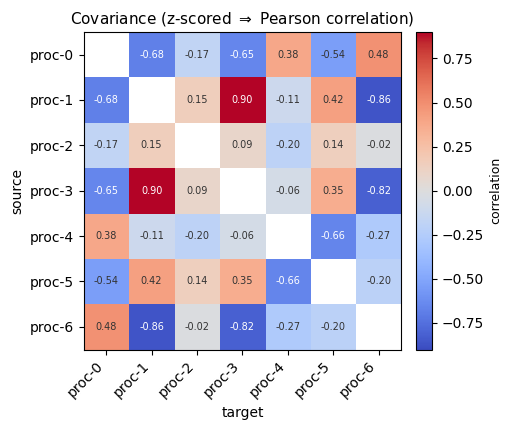

In [17]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))

vmax = np.nanmax(np.abs(cov.values))
im = ax.imshow(cov.values, cmap="coolwarm", vmin=-vmax, vmax=vmax)

ax.set_xticks(range(data.n_processes), data.procnames, rotation=45, ha="right")
ax.set_yticks(range(data.n_processes), data.procnames)
ax.set_title("Covariance (z-scored $\\Rightarrow$ Pearson correlation)", fontsize=11)
ax.set_xlabel("target")
ax.set_ylabel("source")

for i in range(data.n_processes):
    for j in range(data.n_processes):
        if i != j:
            v = cov.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.6 * vmax else "#333333")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation", fontsize=9)
# ax.spines[:].set_visible(True)
fig.tight_layout()
plt.show()

## 6. The same run from the command line

Everything above is available without writing Python. Save your data as an `.npy` array
and run:

```bash
python -m pyspi compute --data ts.npy --config fabfour --n-jobs 4 --checkpoint-dir results/
```

`--checkpoint-dir` writes each finished SPI to disk as it completes, so an interrupted
run resumes instead of restarting. The same applies in Python:
`calc.compute(checkpoint_dir="results/", resume=True)`.

## Next

`02_comparing_spis.ipynb` builds a dataset with known couplings and shows where the
choice of SPI actually changes the answer.